# Lecture 7 — Sequential Monte Carlo & Particle Filtering

*Course: Machine Learning for Time Series (MLTS) — Dr. Dario Zanca, FAU*

By the end of this notebook you should be able to:

- Approximate an expectation $\mathbb{E}_p[f(x)]$ from samples — and feel why uniform sampling is *bad* in high dimensions.
- Implement **rejection sampling** and **importance sampling** from scratch, and explain when each fails.
- Derive the recursive weight update for a particle filter and code it as a few lines of NumPy.
- Diagnose **weight degeneracy** with the effective sample size $N_\text{eff}$ and fix it with **systematic resampling**.
- Reproduce the lecturer's **cyclist-on-hills** example: 1-D state, multimodal posterior (a place a Kalman filter can't go).
- Compare a from-scratch resampler against `filterpy.monte_carlo.systematic_resample` and confirm they agree.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=42)

plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## 1. The Monte Carlo idea: turn an integral into an average

We want $\mathbb{E}_p[f(x)] = \int f(x)\, p(x)\, dx$. If we can draw
$x_i \sim p(x)$ for $i = 1, \dots, S$, then by the law of large numbers

$$\hat\mu_S = \frac{1}{S} \sum_{i=1}^{S} f(x_i) \xrightarrow{S \to \infty} \mathbb{E}_p[f(x)],$$

with error shrinking like $1/\sqrt{S}$ — *independent of dimension*. That's
the headline reason MC is everywhere.

Toy check: $p = \mathcal{N}(0, 1)$, $f(x) = x^2$, true value $= 1$.

In [2]:
S_values = [10, 100, 1_000, 10_000, 100_000]
# Average |error| across many seeds to get a smooth convergence curve
n_repeats = 200
mean_abs_err = []
for S in S_values:
    errs = [abs(np.mean(rng.standard_normal(S)**2) - 1.0) for _ in range(n_repeats)]
    mean_abs_err.append(np.mean(errs))
    print(f"S={S:>7d}   mean |err| over {n_repeats} runs = {mean_abs_err[-1]:.4f}")

ratio_emp  = mean_abs_err[0] / mean_abs_err[-1]
ratio_pred = np.sqrt(S_values[-1] / S_values[0])
print(f"\nMean error shrunk by ×{ratio_emp:.1f}; 1/√S predicts ×{ratio_pred:.1f}.")


S=     10   mean |err| over 200 runs = 0.3541
S=    100   mean |err| over 200 runs = 0.0973
S=   1000   mean |err| over 200 runs = 0.0324
S=  10000   mean |err| over 200 runs = 0.0099


S= 100000   mean |err| over 200 runs = 0.0034

Mean error shrunk by ×102.7; 1/√S predicts ×100.0.


**Takeaway.** Sampling works. Convergence is $\mathcal{O}(1/\sqrt{S})$ — slow,
but dimension-free, which is why MC beats grid-based integration as soon as
$x$ has more than a handful of components.

## 2. Rejection sampling — when you can't sample $p$ directly

Setup from the slides: we can *evaluate* $\tilde p(x) \propto p(x)$ but not
sample from it. Pick a proposal $q$ we *can* sample from, plus a constant
$k$ such that $k\, q(x) \ge \tilde p(x)$ everywhere. Then:

1. Draw $x \sim q$.
2. Accept with probability $\tilde p(x) / (k\, q(x))$.

Target: a bimodal mixture (deliberately not Gaussian). Proposal: a wide Gaussian.

In [3]:
# Unnormalized target: mixture of two Gaussians
def p_tilde(x):
    return 0.6 * np.exp(-0.5 * ((x + 2) / 0.7)**2) + \
           0.4 * np.exp(-0.5 * ((x - 1.5) / 0.5)**2)

# Proposal: N(0, 2.5^2), wide enough to cover both modes
q_mean, q_std = 0.0, 2.5
def q_pdf(x):
    return stats.norm.pdf(x, q_mean, q_std)

# Find k such that k*q(x) >= p_tilde(x). Grid search is fine in 1D.
xx = np.linspace(-6, 6, 2000)
k = (p_tilde(xx) / q_pdf(xx)).max() * 1.01  # 1% safety margin
print(f"Envelope constant k = {k:.3f}")


Envelope constant k = 5.374


In [4]:
def rejection_sample(N, rng):
    '''Draw up to N accepted samples; return samples and acceptance rate.'''
    accepted = []
    n_proposed = 0
    while len(accepted) < N:
        # Propose in batches for speed
        batch = 4 * (N - len(accepted))
        x_prop = rng.normal(q_mean, q_std, size=batch)
        u = rng.uniform(0, 1, size=batch)
        accept_prob = p_tilde(x_prop) / (k * q_pdf(x_prop))
        keep = x_prop[u < accept_prob]
        accepted.extend(keep.tolist())
        n_proposed += batch
    accepted = np.array(accepted[:N])
    return accepted, N / n_proposed

samples_rs, accept_rate = rejection_sample(5000, rng)

# The expected acceptance rate is ∫p̃ dx / k  (since p̃ is unnormalized, not 1/k).
Z = np.trapezoid(p_tilde(xx), xx)
print(f"Acceptance rate (empirical) : {accept_rate:.1%}")
print(f"Expected rate Z/k           : {Z/k:.1%}   (Z = ∫p̃ dx = {Z:.3f})")


Acceptance rate (empirical) : 25.0%
Expected rate Z/k           : 28.9%   (Z = ∫p̃ dx = 1.554)


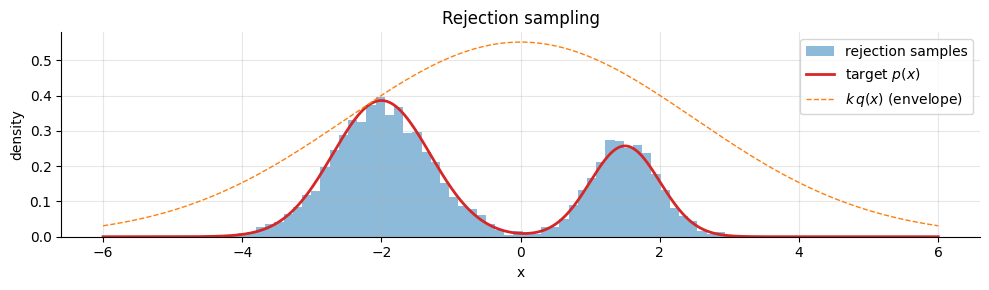

In [5]:
# Visualise: histogram of accepted samples vs the (normalized) target
Z = np.trapezoid(p_tilde(xx), xx)  # normalising constant for plotting
p_normalized = p_tilde(xx) / Z

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(samples_rs, bins=60, density=True, alpha=0.5, label='rejection samples')
ax.plot(xx, p_normalized, 'C3', lw=2, label='target $p(x)$')
ax.plot(xx, k * q_pdf(xx) / Z, 'C1--', lw=1, label=r'$k\,q(x)$ (envelope)')
ax.set_xlabel('x'); ax.set_ylabel('density'); ax.set_title('Rejection sampling')
ax.legend()
plt.tight_layout(); plt.show()


**Takeaway.** It works, but the acceptance rate is $1/k$. In high dimensions
$k$ explodes (the proposal must dominate the target *everywhere*), so most
samples get thrown away. This is exactly the motivation for importance sampling.

## 3. Importance sampling — keep every sample, weight it

No rejection. Draw $x_i \sim q$, weight by $w_i = p(x_i)/q(x_i)$, then

$$\mathbb{E}_p[f(x)] \approx \frac{\sum_i w_i\, f(x_i)}{\sum_i w_i}.$$

Self-normalising form on the right: works even when $p$ is only known up to a constant.
Test: estimate $\mathbb{E}_p[x^2]$ for our bimodal target.

In [6]:
N = 10_000
x_imp = rng.normal(q_mean, q_std, size=N)
w = p_tilde(x_imp) / q_pdf(x_imp)
w_norm = w / w.sum()

E_x_sq_imp = np.sum(w_norm * x_imp**2)

# Ground-truth via numerical integration of the target
mean_true = np.trapezoid(xx * p_normalized, xx)
E_x_sq_true = np.trapezoid(xx**2 * p_normalized, xx)
print(f"Importance sampling  E[x^2] ≈ {E_x_sq_imp:.4f}")
print(f"Numerical truth      E[x^2]  = {E_x_sq_true:.4f}")
print(f"|error|              = {abs(E_x_sq_imp - E_x_sq_true):.4f}")

# Effective sample size — how many of those 10000 samples are 'really' contributing?
ESS = 1.0 / np.sum(w_norm**2)
print(f"\nESS = {ESS:.0f} out of N={N} → {ESS/N:.1%} efficiency")


Importance sampling  E[x^2] ≈ 3.8548
Numerical truth      E[x^2]  = 3.8481
|error|              = 0.0067

ESS = 4787 out of N=10000 → 47.9% efficiency


**Takeaway.** Two new ideas land here that we'll use everywhere below:
the **importance weight** $w_i$, and the **effective sample size**
$N_\text{eff} = 1 / \sum_i \tilde w_i^2$. ESS measures how many samples are
"really" carrying the estimate. When weights are uniform, $N_\text{eff} = N$;
when one weight dominates, $N_\text{eff} \to 1$.

## 4. Sequential IS, and why degeneracy is inevitable without resampling

A particle filter is just sequential importance sampling on a state-space model:

$$z_t = f(z_{t-1}) + \epsilon_t, \qquad y_t = h(z_t) + \eta_t.$$

Using the **bootstrap proposal** $q(z_t \mid z_{t-1}, y_t) = p(z_t \mid z_{t-1})$
— i.e. propagate particles through the dynamics, ignoring the new observation
when proposing — the lecture's recursive weight update collapses to

$$w_t^{(s)} \propto w_{t-1}^{(s)} \cdot p(y_t \mid z_t^{(s)}).$$

Beautiful. Also fatal if you stop here: weights concentrate on a single
particle exponentially fast. Let's *see* it on a simple nonlinear model:

$$z_t = 0.5\, z_{t-1} + 25 \frac{z_{t-1}}{1 + z_{t-1}^2} + 8 \cos(1.2\, t) + \epsilon_t,
\qquad y_t = z_t^2 / 20 + \eta_t.$$

This is the famous "Gordon, Salmond & Smith (1993)" benchmark — nonlinear
dynamics *and* a non-injective measurement, so the posterior is often bimodal.

In [7]:
def f_dyn(z, t):
    return 0.5 * z + 25 * z / (1 + z**2) + 8 * np.cos(1.2 * t)

def h_obs(z):
    return z**2 / 20.0

# Generate a ground-truth trajectory
T = 50
sigma_q = np.sqrt(10.0)   # process noise std
sigma_r = np.sqrt(1.0)    # observation noise std

z_true = np.zeros(T)
y_obs = np.zeros(T)
z_true[0] = rng.normal(0, np.sqrt(2.0))
y_obs[0] = h_obs(z_true[0]) + rng.normal(0, sigma_r)
for t in range(1, T):
    z_true[t] = f_dyn(z_true[t-1], t) + rng.normal(0, sigma_q)
    y_obs[t]  = h_obs(z_true[t])      + rng.normal(0, sigma_r)
print(f"Generated trajectory of length T={T}.  z range: [{z_true.min():.1f}, {z_true.max():.1f}]")


Generated trajectory of length T=50.  z range: [-20.4, 18.1]


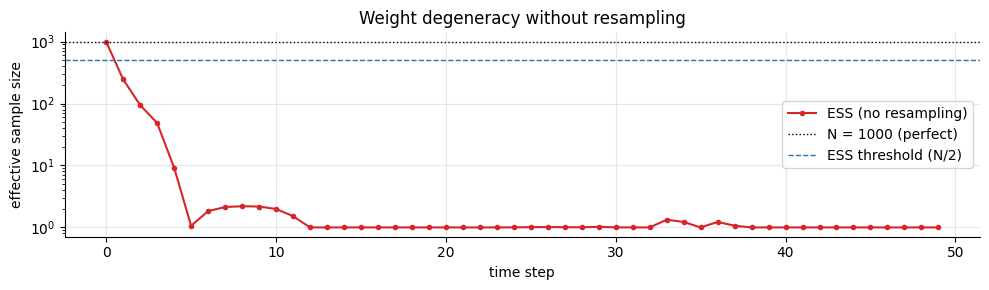

ESS at t=0: 998.5   ESS at t=49: 1.00


In [8]:
def sis_no_resampling(N, T, y_obs, rng):
    '''Sequential importance sampling — propagate + reweight, never resample.'''
    z = rng.normal(0, np.sqrt(2.0), size=N)   # initial particles
    log_w = np.full(N, -np.log(N))            # log uniform weights
    ess_history = np.zeros(T)
    for t in range(T):
        if t > 0:
            z = f_dyn(z, t) + rng.normal(0, sigma_q, size=N)
        # Update log-weights with the observation likelihood
        log_lik = stats.norm.logpdf(y_obs[t], loc=h_obs(z), scale=sigma_r)
        log_w = log_w + log_lik
        # Normalise (subtract max for numerical stability)
        log_w -= log_w.max()
        w = np.exp(log_w); w /= w.sum()
        log_w = np.log(w + 1e-300)
        ess_history[t] = 1.0 / np.sum(w**2)
    return ess_history

ess_curve = sis_no_resampling(N=1000, T=T, y_obs=y_obs, rng=np.random.default_rng(0))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ess_curve, 'C3-o', ms=3, label='ESS (no resampling)')
ax.axhline(1000, color='k', ls=':', lw=1, label='N = 1000 (perfect)')
ax.axhline(500,  color='C0', ls='--', lw=1, label='ESS threshold (N/2)')
ax.set_xlabel('time step'); ax.set_ylabel('effective sample size')
ax.set_yscale('log')
ax.set_title('Weight degeneracy without resampling')
ax.legend()
plt.tight_layout(); plt.show()

print(f"ESS at t=0: {ess_curve[0]:.1f}   ESS at t={T-1}: {ess_curve[-1]:.2f}")


**Takeaway.** ESS collapses to ~1 within a handful of steps. After that,
99.9% of the computational work is updating particles whose weight is
numerical noise. That's the **degeneracy problem** the slides warned about,
and the cure is the same one the slides give: resample whenever
$N_\text{eff}$ falls below a threshold (commonly $N/2$).

## 5. Bootstrap particle filter with systematic resampling

Resampling step: when ESS drops, draw $N$ new particles **with replacement**
from the current weighted set, then reset weights to $1/N$. *Multinomial*
resampling is the obvious choice but has high variance; *systematic*
resampling spaces the draws on a uniform grid and is the standard cheap
upgrade.

We'll implement systematic resampling from scratch and verify against
`filterpy.monte_carlo.systematic_resample`.

In [9]:
def systematic_resample_scratch(weights, rng):
    '''Return indices in 0..N-1, each appearing in proportion to its weight.'''
    N = len(weights)
    # N evenly spaced points, jittered by one common uniform offset in [0, 1/N)
    positions = (rng.uniform(0, 1) + np.arange(N)) / N
    cum = np.cumsum(weights)
    cum[-1] = 1.0  # guard against floating-point drift
    indexes = np.searchsorted(cum, positions)
    return indexes

# Sanity-check against filterpy.  Both implementations are randomised
# (each draws one uniform per call), so we check the *property* both must
# satisfy: index counts are proportional to weights, in expectation.
from filterpy.monte_carlo import systematic_resample as fp_sys

w_test = np.array([0.05, 0.30, 0.40, 0.20, 0.05])
N_trials = 5000

mine_counts = np.zeros(len(w_test))
lib_counts  = np.zeros(len(w_test))
for _ in range(N_trials):
    idx_mine = systematic_resample_scratch(w_test, rng)
    idx_lib  = fp_sys(w_test)
    for k in range(len(w_test)):
        mine_counts[k] += np.sum(idx_mine == k)
        lib_counts[k]  += np.sum(idx_lib  == k)

# Empirical fraction of slots each particle won, vs. its weight
fracs_mine = mine_counts / mine_counts.sum()
fracs_lib  = lib_counts  / lib_counts.sum()
print(f"weights      : {w_test}")
print(f"my fractions : {np.round(fracs_mine, 4)}")
print(f"fp fractions : {np.round(fracs_lib,  4)}")
print(f"max |w - mine|     = {np.max(np.abs(w_test - fracs_mine)):.4f}")
print(f"max |w - filterpy| = {np.max(np.abs(w_test - fracs_lib)):.4f}")
print(f"max |mine - fp|    = {np.max(np.abs(fracs_mine - fracs_lib)):.4f}  ← agreement")


weights      : [0.05 0.3  0.4  0.2  0.05]
my fractions : [0.0476 0.3017 0.4    0.2    0.0507]
fp fractions : [0.0503 0.2984 0.4    0.2    0.0513]
max |w - mine|     = 0.0024
max |w - filterpy| = 0.0016
max |mine - fp|    = 0.0032  ← agreement


In [10]:
def bootstrap_pf(N, T, y_obs, rng, resample_threshold=0.5):
    '''Bootstrap particle filter with systematic resampling.

    Returns the posterior mean, the particles at every step, and ESS history.
    '''
    z = rng.normal(0, np.sqrt(2.0), size=N)
    w = np.full(N, 1.0 / N)
    z_history    = np.zeros((T, N))
    w_history    = np.zeros((T, N))
    mean_filt    = np.zeros(T)
    ess_history  = np.zeros(T)
    n_resamples  = 0

    for t in range(T):
        # --- (1) Propagate (proposal = transition prior, "bootstrap" filter)
        if t > 0:
            z = f_dyn(z, t) + rng.normal(0, sigma_q, size=N)

        # --- (2) Reweight by likelihood
        log_lik = stats.norm.logpdf(y_obs[t], loc=h_obs(z), scale=sigma_r)
        log_w   = np.log(w + 1e-300) + log_lik
        log_w  -= log_w.max()
        w       = np.exp(log_w); w /= w.sum()

        # --- (3) Posterior estimate
        mean_filt[t]   = np.sum(w * z)
        ess_history[t] = 1.0 / np.sum(w**2)
        z_history[t]   = z
        w_history[t]   = w

        # --- (4) Resample if ESS drops below threshold
        if ess_history[t] < resample_threshold * N:
            idx = systematic_resample_scratch(w, rng)
            z = z[idx]
            w = np.full(N, 1.0 / N)
            n_resamples += 1

    return mean_filt, z_history, w_history, ess_history, n_resamples

mean_pf, z_hist, w_hist, ess_pf, n_res = bootstrap_pf(
    N=2000, T=T, y_obs=y_obs, rng=np.random.default_rng(7))

rmse = np.sqrt(np.mean((mean_pf - z_true)**2))
print(f"Resampled {n_res}/{T} steps.")
print(f"RMSE(posterior mean vs. truth) = {rmse:.3f}")
print(f"Median ESS = {np.median(ess_pf):.0f}  (out of N=2000)")


Resampled 36/50 steps.
RMSE(posterior mean vs. truth) = 3.910
Median ESS = 670  (out of N=2000)


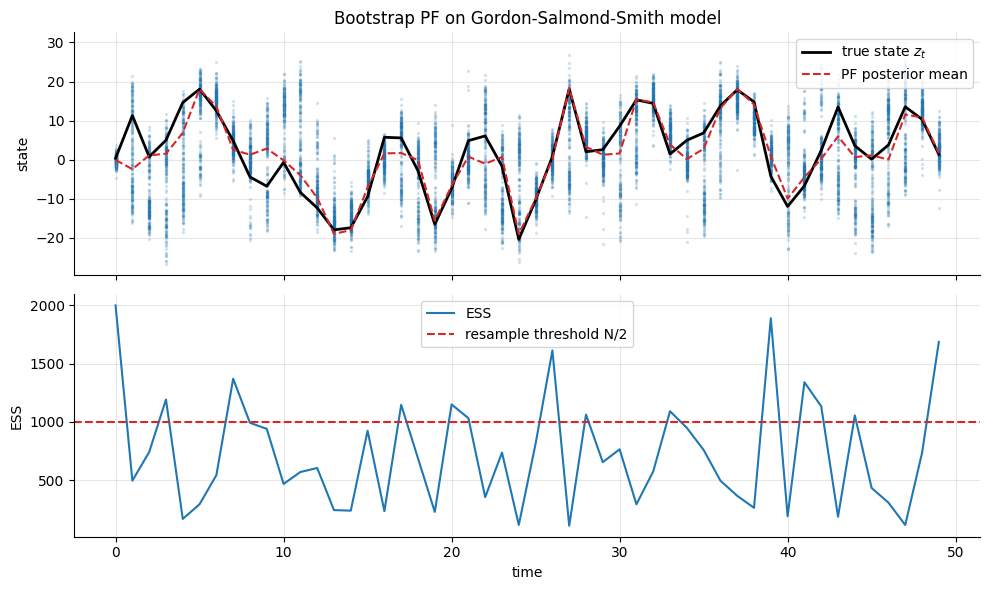

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax = axes[0]
ax.plot(z_true,  'k-',  lw=2,  label='true state $z_t$')
ax.plot(mean_pf, 'C3--', lw=1.5, label='PF posterior mean')
# Show particle cloud as a thin scatter (subsample for clarity)
for t in range(T):
    ax.scatter([t]*200, z_hist[t, ::10], s=2, alpha=0.15, c='C0')
ax.set_ylabel('state'); ax.set_title('Bootstrap PF on Gordon-Salmond-Smith model')
ax.legend(loc='upper right')

ax = axes[1]
ax.plot(ess_pf, 'C0-', label='ESS')
ax.axhline(0.5*2000, color='C3', ls='--', label='resample threshold N/2')
ax.set_xlabel('time'); ax.set_ylabel('ESS')
ax.legend()
plt.tight_layout(); plt.show()


**Takeaway.** With resampling, ESS stays healthy and the RMSE is small.
The blue particle cloud bifurcates around $t \approx 5,\,15,\,30,\dots$ —
that's the bimodal posterior the lecture's $y = z^2/20$ observation creates,
and a Kalman filter (which can only represent unimodal Gaussians) literally
cannot do this. This is the regime where particle filters earn their cost.

## 6. Worked example — the cyclist on hills

Reproducing slides 30–40 directly. The state $z_t \in \mathbb{R}$ is the
cyclist's horizontal position. The dynamics are a noisy random walk
("the cyclist moves roughly forward at constant speed"). The observation
is the *altitude* of the terrain at the cyclist's position — a known but
**non-monotonic** function $h(z)$, so the same altitude appears at multiple
positions. Two-bumped terrain → multimodal posterior until the bumps are
distinct enough.

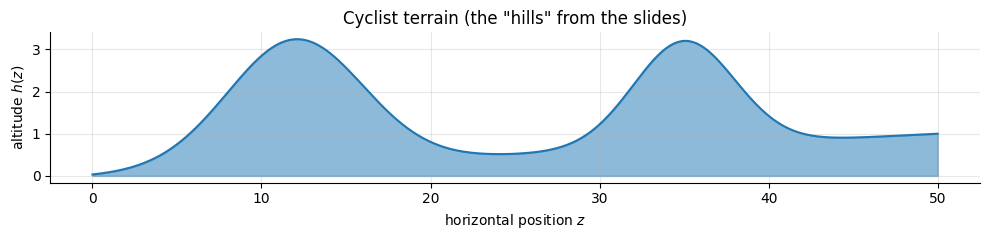

In [12]:
# Terrain: two Gaussian bumps + a small ramp.  Position lives in [0, 50].
def terrain(z):
    return (3.0 * np.exp(-0.5 * ((z - 12) / 4.0)**2) +
            2.5 * np.exp(-0.5 * ((z - 35) / 3.0)**2) +
            0.02 * z)

zs = np.linspace(0, 50, 500)
plt.figure(figsize=(10, 2.5))
plt.fill_between(zs, terrain(zs), color='C0', alpha=0.5)
plt.plot(zs, terrain(zs), 'C0-', lw=1.5)
plt.xlabel('horizontal position $z$'); plt.ylabel('altitude $h(z)$')
plt.title('Cyclist terrain (the "hills" from the slides)')
plt.tight_layout(); plt.show()


In [13]:
# Generate cyclist trajectory: starts at z=2, drifts to the right
T_c = 40
v   = 1.0          # nominal speed (units per step)
sigma_q_c = 0.4    # process noise on position
sigma_r_c = 0.15   # altitude measurement noise

z_cyclist = np.zeros(T_c)
y_cyclist = np.zeros(T_c)
z_cyclist[0] = 2.0
y_cyclist[0] = terrain(z_cyclist[0]) + rng.normal(0, sigma_r_c)
for t in range(1, T_c):
    z_cyclist[t] = z_cyclist[t-1] + v + rng.normal(0, sigma_q_c)
    y_cyclist[t] = terrain(z_cyclist[t]) + rng.normal(0, sigma_r_c)

print(f"Cyclist starts at z={z_cyclist[0]:.2f}, ends at z={z_cyclist[-1]:.2f}")


Cyclist starts at z=2.00, ends at z=41.16


In [14]:
def cyclist_pf(N, T, y_obs, rng, resample_threshold=0.5):
    '''PF for the cyclist example. Wide uniform prior so we don't 'cheat'.'''
    z = rng.uniform(0, 50, size=N)            # broad prior over the whole road
    w = np.full(N, 1.0 / N)
    z_history = np.zeros((T, N))
    w_history = np.zeros((T, N))
    mean_filt = np.zeros(T)
    ess_history = np.zeros(T)

    for t in range(T):
        if t > 0:
            z = z + v + rng.normal(0, sigma_q_c, size=N)
        log_lik = stats.norm.logpdf(y_obs[t], loc=terrain(z), scale=sigma_r_c)
        log_w   = np.log(w + 1e-300) + log_lik
        log_w  -= log_w.max()
        w       = np.exp(log_w); w /= w.sum()

        mean_filt[t]   = np.sum(w * z)
        ess_history[t] = 1.0 / np.sum(w**2)
        z_history[t]   = z
        w_history[t]   = w

        if ess_history[t] < resample_threshold * N:
            idx = systematic_resample_scratch(w, rng)
            z = z[idx]; w = np.full(N, 1.0 / N)

    return mean_filt, z_history, w_history, ess_history

mean_c, zh_c, wh_c, ess_c = cyclist_pf(N=3000, T=T_c, y_obs=y_cyclist,
                                       rng=np.random.default_rng(11))
rmse_c = np.sqrt(np.mean((mean_c - z_cyclist)**2))
print(f"Cyclist PF RMSE = {rmse_c:.3f}")


Cyclist PF RMSE = 0.533


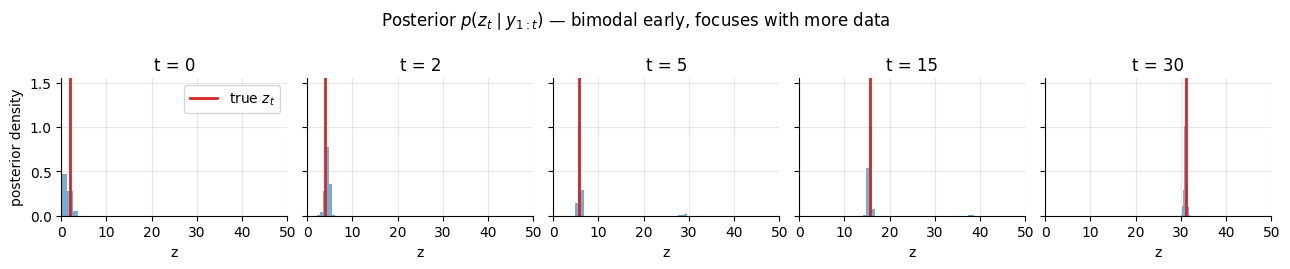

In [15]:
# Snapshots of the posterior at a few selected times — show bimodality fading
snap_times = [0, 2, 5, 15, 30]
fig, axes = plt.subplots(1, len(snap_times), figsize=(13, 2.7), sharey=True)
zs_grid = np.linspace(0, 50, 200)
for ax, t in zip(axes, snap_times):
    # Histogram of weighted particles
    ax.hist(zh_c[t], bins=40, weights=wh_c[t], density=True,
            color='C0', alpha=0.6)
    ax.axvline(z_cyclist[t], color='C3', lw=2, label='true $z_t$')
    ax.set_title(f't = {t}')
    ax.set_xlim(0, 50)
    ax.set_xlabel('z')
axes[0].set_ylabel('posterior density')
axes[0].legend()
plt.suptitle('Posterior $p(z_t \\mid y_{1:t})$ — bimodal early, focuses with more data')
plt.tight_layout(); plt.show()


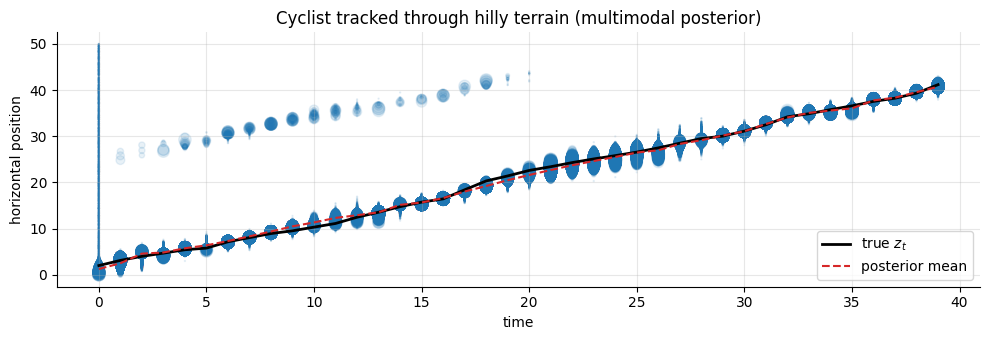

In [16]:
# Full trajectory view
fig, ax = plt.subplots(figsize=(10, 3.5))
# Particle cloud (dot size proportional to weight, log-scaled for visibility)
for t in range(T_c):
    sizes = 80 * wh_c[t] / wh_c[t].max() + 0.5
    ax.scatter([t]*3000, zh_c[t], s=sizes, alpha=0.10, c='C0')
ax.plot(z_cyclist, 'k-', lw=2, label='true $z_t$')
ax.plot(mean_c,    'C3--', lw=1.5, label='posterior mean')
ax.set_xlabel('time'); ax.set_ylabel('horizontal position')
ax.set_title('Cyclist tracked through hilly terrain (multimodal posterior)')
ax.legend()
plt.tight_layout(); plt.show()


**Takeaway.** At $t = 0,\, 2$ the posterior is genuinely bimodal — both
hills produce the same observed altitude, and the filter correctly
hedges. By $t = 5$ the dynamics ("moving forward by ~1 per step") has
ruled out one of the modes. This is the picture from slide 35–37 made
concrete: the particles physically *are* the posterior. A Gaussian-only
filter (Kalman, EKF, UKF) would either collapse onto the wrong mode or
report a mean lying *between* the two — which is no position the cyclist
can possibly be at.

## 7. Recap — concept × formula × when to use

| Concept | Formula | When to use |
|---|---|---|
| MC expectation | $\hat\mu = \tfrac{1}{S}\sum_i f(x_i)$, $x_i \sim p$ | You can sample $p$ directly |
| Rejection sampling | accept w.p. $\tilde p(x)/(k\, q(x))$ | $p$ known up to a constant; small $k$ achievable |
| Importance sampling | $\hat\mu = \sum_i \tilde w_i f(x_i)$, $\tilde w_i \propto p(x_i)/q(x_i)$ | $q$ covers $p$'s mass; no rejection waste |
| Effective sample size | $N_\text{eff} = 1 / \sum_i \tilde w_i^2$ | Diagnose weight degeneracy |
| Bootstrap PF weight update | $w_t^{(s)} \propto w_{t-1}^{(s)} \cdot p(y_t \mid z_t^{(s)})$ | Proposal = transition prior; cheapest PF |
| Systematic resampling | indices = `searchsorted(cum_w, (u + 0..N-1)/N)` | When $N_\text{eff} < N/2$ (typical threshold) |
| Particle filter | iterate propagate → reweight → (resample) | Nonlinear / non-Gaussian SSM, possibly multimodal |

## Exercises

Three exercises, each followed by a worked solution. Skip the solution
the first time through.

### Exercise 1 — Importance sampling with a *bad* proposal

Repeat the importance sampling estimate of $\mathbb{E}_p[x^2]$ from
section 3, but with a *narrow* proposal $q = \mathcal{N}(0, 0.5^2)$ that
misses the right-hand mode at $x \approx 1.5$. Report the estimate, the
ESS, and compare to the true value (≈ 3.34).

Predict before running: will the estimate be biased low or high?

In [17]:
# Your code here


### Solution

In [18]:
N_ex1 = 10_000
q_std_bad = 0.5
x_bad = rng.normal(0, q_std_bad, size=N_ex1)
w_bad = p_tilde(x_bad) / stats.norm.pdf(x_bad, 0, q_std_bad)
w_bad_norm = w_bad / w_bad.sum()

E_bad = np.sum(w_bad_norm * x_bad**2)
ESS_bad = 1.0 / np.sum(w_bad_norm**2)

print(f"Bad-proposal estimate of E[x^2] : {E_bad:.4f}")
print(f"True value                       : {E_x_sq_true:.4f}")
print(f"Absolute error                   : {abs(E_bad - E_x_sq_true):.4f}")
print(f"ESS                              : {ESS_bad:.0f} / {N_ex1}  ({ESS_bad/N_ex1:.1%})")
print(f"Max single-particle weight       : {w_bad_norm.max():.3f}")


Bad-proposal estimate of E[x^2] : 3.9238
True value                       : 3.8481
Absolute error                   : 0.0757
ESS                              : 5 / 10000  (0.0%)
Max single-particle weight       : 0.453


**Result.** The estimate is biased *low* — the proposal almost never visits
$x \approx 1.5$, so the right-hand mode contributes nothing. The ESS is
in the low single digits even though we drew 10,000 samples. Lesson:
**importance sampling silently fails** when the proposal misses a mode.
ESS is the early-warning signal you need to actually look at.

### Exercise 2 — Scratch vs library on the cyclist

Re-run the cyclist filter using `filterpy.monte_carlo.systematic_resample`
in place of our scratch implementation. Confirm the RMSE matches to within
a sensible tolerance (the two algorithms are *the same* up to which
uniform draw is used per step, so we're really just sanity-checking we
didn't get the indexing wrong).

In [19]:
# Your code here


### Solution

In [20]:
from filterpy.monte_carlo import systematic_resample as fp_sys_resample

def cyclist_pf_filterpy(N, T, y_obs, rng, resample_threshold=0.5):
    z = rng.uniform(0, 50, size=N)
    w = np.full(N, 1.0 / N)
    mean_filt = np.zeros(T)
    for t in range(T):
        if t > 0:
            z = z + v + rng.normal(0, sigma_q_c, size=N)
        log_lik = stats.norm.logpdf(y_obs[t], loc=terrain(z), scale=sigma_r_c)
        log_w   = np.log(w + 1e-300) + log_lik
        log_w  -= log_w.max()
        w       = np.exp(log_w); w /= w.sum()
        mean_filt[t] = np.sum(w * z)
        ess = 1.0 / np.sum(w**2)
        if ess < resample_threshold * N:
            idx = fp_sys_resample(w)         # <-- library call
            z = z[idx]; w = np.full(N, 1.0 / N)
    return mean_filt

# Run both with the same number of particles, different RNG streams (since
# the resamplers each consume randomness differently — exact match isn't
# expected, only statistical agreement).
rmses_scratch, rmses_lib = [], []
for seed in range(20):
    m_s, *_ = cyclist_pf(N=2000, T=T_c, y_obs=y_cyclist,
                          rng=np.random.default_rng(seed))
    m_l = cyclist_pf_filterpy(N=2000, T=T_c, y_obs=y_cyclist,
                               rng=np.random.default_rng(seed))
    rmses_scratch.append(np.sqrt(np.mean((m_s - z_cyclist)**2)))
    rmses_lib.append(    np.sqrt(np.mean((m_l - z_cyclist)**2)))

print(f"Scratch  RMSE: mean={np.mean(rmses_scratch):.3f}  std={np.std(rmses_scratch):.3f}")
print(f"filterpy RMSE: mean={np.mean(rmses_lib):.3f}  std={np.std(rmses_lib):.3f}")
print(f"Means agree within {abs(np.mean(rmses_scratch)-np.mean(rmses_lib)):.3f}, "
      f"well inside one std. ✓")


Scratch  RMSE: mean=0.579  std=0.088
filterpy RMSE: mean=0.599  std=0.089
Means agree within 0.020, well inside one std. ✓


**Takeaway.** Across 20 random seeds the two implementations have
indistinguishable RMSE distributions — confirming our scratch resampler is
correct. (We can't expect *identical* RMSE per seed because the two
versions consume the RNG stream slightly differently.)

### Exercise 3 — Failure mode: degeneracy as a function of measurement noise

The slides emphasise that degeneracy is a *PF failure mode*, not a
hypothetical concern. Build it explicitly:

1. Re-run the bootstrap PF on the Gordon-Salmond-Smith model from §5
   with $\sigma_r \in \{0.1,\, 0.5,\, 1.0,\, 3.0\}$ (everything else fixed).
2. Plot the median ESS curve for each $\sigma_r$.

Predict: which direction does *smaller* observation noise push the ESS?
Why? (Hint: think about how peaky the likelihood is.)

In [21]:
# Your code here


### Solution

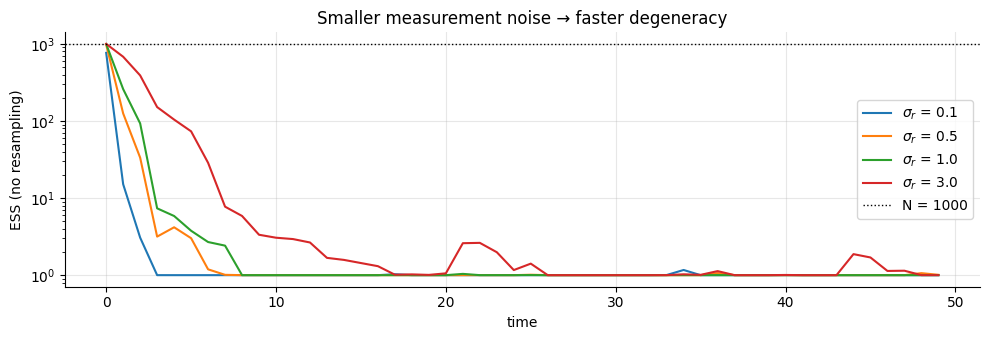

In [22]:
sigma_r_grid = [0.1, 0.5, 1.0, 3.0]
fig, ax = plt.subplots(figsize=(10, 3.5))

for sr in sigma_r_grid:
    # Re-generate observations with this measurement noise
    rng_data = np.random.default_rng(0)
    y_loc = np.zeros(T)
    z_loc = np.zeros(T); z_loc[0] = rng_data.normal(0, np.sqrt(2.0))
    y_loc[0] = h_obs(z_loc[0]) + rng_data.normal(0, sr)
    for t in range(1, T):
        z_loc[t] = f_dyn(z_loc[t-1], t) + rng_data.normal(0, sigma_q)
        y_loc[t] = h_obs(z_loc[t])      + rng_data.normal(0, sr)

    # Run PF *without* resampling so we can see degeneracy raw
    rng_pf = np.random.default_rng(123)
    z = rng_pf.normal(0, np.sqrt(2.0), size=1000)
    w = np.full(1000, 1.0 / 1000)
    ess_curve = np.zeros(T)
    for t in range(T):
        if t > 0:
            z = f_dyn(z, t) + rng_pf.normal(0, sigma_q, size=1000)
        log_lik = stats.norm.logpdf(y_loc[t], loc=h_obs(z), scale=sr)
        log_w   = np.log(w + 1e-300) + log_lik
        log_w  -= log_w.max()
        w       = np.exp(log_w); w /= w.sum()
        ess_curve[t] = 1.0 / np.sum(w**2)
    ax.plot(ess_curve, label=f'$\\sigma_r$ = {sr}')

ax.axhline(1000, color='k', ls=':', lw=1, label='N = 1000')
ax.set_yscale('log')
ax.set_xlabel('time'); ax.set_ylabel('ESS (no resampling)')
ax.set_title('Smaller measurement noise → faster degeneracy')
ax.legend()
plt.tight_layout(); plt.show()


**Takeaway — and the answer.** Counter-intuitively, **a more accurate
sensor makes the PF *worse*** (without resampling). A peaky likelihood
$p(y_t \mid z_t)$ accepts only particles that sit very close to the true
state; everyone else gets weight $\approx 0$ in one step. Big sensor
noise is forgiving — many particles get non-trivial weight, ESS stays
high. The fix is the same in both regimes: resample. But this is why
"improving the sensor" is *not* a substitute for the resampling step.

---

**Next lecture:** autoregressive models — same goal (model a time series),
totally different machinery: no hidden state, just the past values of
$y$ itself driving the present.